In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

## Data Preparation

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [3]:
!wget $data

--2026-05-27 06:11:51--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  --.-KB/s    in 0.04s   

2026-05-27 06:11:52 (18.7 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



In [4]:
df = pd.read_csv('/content/car_fuel_efficiency.csv')

In [5]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [6]:
df.dtypes == 'object'

,0
engine_displacement,False
num_cylinders,False
horsepower,False
vehicle_weight,False
acceleration,False
model_year,False
origin,True
fuel_type,True
drivetrain,True
num_doors,False


In [7]:
strings = list(df.dtypes[df.dtypes == 'object'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [8]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [9]:
print("{} : \n {} \n".format('total houses (rows)', len(df)))

total houses (rows) : 
 9704 



In [10]:
df.head(10)

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,europe,gasoline,all-wheel_drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,usa,gasoline,front-wheel_drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,europe,gasoline,front-wheel_drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,usa,diesel,all-wheel_drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,europe,gasoline,all-wheel_drive,2.0,12.488369
5,190,3.0,NaN,2484.883986,14.7,2008,europe,gasoline,all-wheel_drive,-1.0,17.271818
6,240,7.0,127.0,3006.542287,22.2,2012,usa,gasoline,front-wheel_drive,1.0,13.210412
7,150,4.0,239.0,3638.657780,17.3,2020,usa,diesel,all-wheel_drive,1.0,12.848884
8,250,1.0,174.0,2714.219310,10.3,2016,asia,diesel,front-wheel_drive,-1.0,16.823554
9,150,4.0,123.0,3509.036569,10.2,2005,usa,gasoline,front-wheel_drive,-1.0,12.298355


In [11]:
len(df)

9704

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   num_cylinders        9222 non-null   float64
 2   horsepower           8996 non-null   float64
 3   vehicle_weight       9704 non-null   float64
 4   acceleration         8774 non-null   float64
 5   model_year           9704 non-null   int64  
 6   origin               9704 non-null   object 
 7   fuel_type            9704 non-null   object 
 8   drivetrain           9704 non-null   object 
 9   num_doors            9202 non-null   float64
 10  fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 834.1+ KB


In [14]:
selected_columns = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

filtered_df = df[selected_columns]

print(filtered_df.head())

   engine_displacement  horsepower  vehicle_weight  model_year  \
0                  170       159.0     3413.433759        2003   
1                  130        97.0     3149.664934        2007   
2                  170        78.0     3079.038997        2018   
3                  220         NaN     2542.392402        2009   
4                  210       140.0     3460.870990        2009   

   fuel_efficiency_mpg  
0            13.231729  
1            13.688217  
2            14.246341  
3            16.912736  
4            12.488369  


## Exploratory data analysis (EDA)

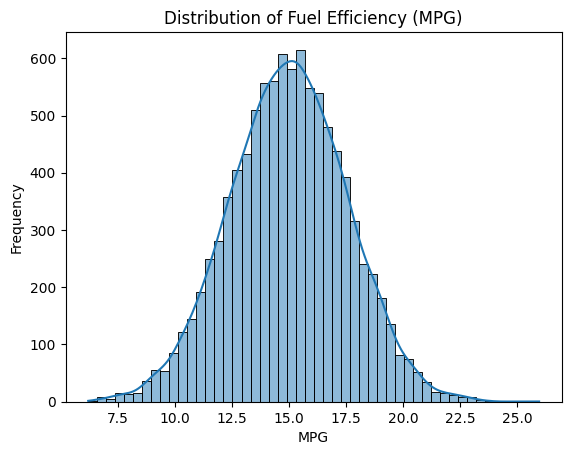

In [15]:
sns.histplot(df.fuel_efficiency_mpg, bins=50, kde=True)
plt.title('Distribution of Fuel Efficiency (MPG)')
plt.xlabel('MPG')
plt.ylabel('Frequency')
plt.show()

Q1: There's one column with missing values. What is it?

In [16]:
# Count missing values in each selected column
missing_counts = df[selected_columns].isnull().sum()
print(missing_counts)

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


In [17]:
missing_column_name = df[selected_columns].columns[df[selected_columns].isnull().any()]
print(f"The column with missing values is:{missing_column_name.values}")

The column with missing values is:['horsepower']


In [18]:
# Mean
mean_hp = df['horsepower'].mean()
print("Mean horsepower:", mean_hp)

Mean horsepower: 149.65729212983547


In [19]:
# Median
median_value = df['horsepower'].median()
print("Median horsepower:", median_value)

Median horsepower: 149.0


In [20]:
# Mode
mode_value = df['horsepower'].mode()
print("Median horsepower:", mode_value)

Median horsepower: 0    152.0
Name: horsepower, dtype: float64


Q2: What's the median (50% percentile) for variable `'horsepower'`?

In [21]:
median_hp = df['horsepower'].median()
print("Median horsepower:", median_hp)

Median horsepower: 149.0


In [22]:
df['horsepower'].isnull().sum()

np.int64(708)

In [23]:
print("Mean horsepower used for filling:", df['horsepower'].mean())

Mean horsepower used for filling: 149.65729212983547


In [24]:
print("filling horsepower with 0:", df['horsepower'].fillna(0))

filling horsepower with 0: 0       159.0
1        97.0
2        78.0
3         0.0
4       140.0
        ...  
9699    164.0
9700    154.0
9701    138.0
9702    177.0
9703    140.0
Name: horsepower, Length: 9704, dtype: float64


## Setting up the validation framework

Round the RMSE scores to 2 decimal digits using `round(score, 2)`
* Q3: Which option gives better RMSE?

In [34]:
# splitting and preparing the dataset
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

In [35]:
n

9704

In [36]:
n, n_test, n_val, n_train

(9704, 1940, 1940, 5824)

In [37]:
df.loc[[10, 0, 3, 5], selected_columns]

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
10,230,100.0,3111.810181,2014,13.386605
0,170,159.0,3413.433759,2003,13.231729
3,220,NaN,2542.392402,2009,16.912736
5,190,NaN,2484.883986,2008,17.271818


In [38]:
idx = np.arange(n)

In [39]:
np.random.seed(42)
np.random.shuffle(idx)

In [40]:
df_shuffled = df.iloc[idx]

In [41]:
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [42]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [43]:
df_train.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,220,3.0,144.0,2535.887591,18.7,2009,usa,gasoline,all-wheel_drive,2.0,16.642943
1,160,2.0,141.0,2741.170484,14.3,2019,asia,diesel,front-wheel_drive,2.0,16.298377
2,230,3.0,155.0,2471.880237,NaN,2017,asia,diesel,front-wheel_drive,2.0,18.591822
3,150,3.0,206.0,3748.164469,15.5,2015,usa,gasoline,all-wheel_drive,1.0,11.818843
4,300,4.0,111.0,2135.716359,16.9,2006,usa,gasoline,all-wheel_drive,NaN,19.402209


In [44]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [45]:
np.log1p(df_train.horsepower)

,horsepower
0,4.976734
1,4.955827
2,5.049856
3,5.332719
4,4.718499
...,...
5819,4.941642
5820,4.890349
5821,5.030438
5822,5.043425


In [46]:
np.log1p(df_train.horsepower.values)

array([4.97673374, 4.95582706, 5.04985601, ..., 5.03043792, 5.04342512,
       5.03043792])

In [47]:
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

In [48]:
y_val

,fuel_efficiency_mpg
0,15.366341
1,14.601182
2,12.247032
3,15.136400
4,10.340419
...,...
1935,13.868607
1936,15.665403
1937,13.613127
1938,13.733343


In [49]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [50]:
len(y_train)

5824

In [51]:
df_train.iloc[10]

,10
engine_displacement,240
num_cylinders,2.0
horsepower,159.0
vehicle_weight,2916.987921
acceleration,16.3
model_year,2001
origin,asia
fuel_type,gasoline
drivetrain,front-wheel_drive
num_doors,1.0


In [52]:
np.exp(8.252132832)

np.float64(3835.7982163505876)

In [53]:
np.expm1(8.252132832)

np.float64(3834.7982163505876)

In [54]:
np.log1p(3834.7982163505876)

np.float64(8.252132832)

In [55]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.pinv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [59]:
df_train.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors'],
      dtype='object')

In [56]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

Options:
* With 0

In [58]:
def prepare_X_zero(df):
    df = df.copy()
    df.horsepower = df.horsepower.fillna(0)

    X = df.values

    return X

In [ ]:
X_train = prepare_X_zero(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_zero(df_val)
y_pred = w0 + X_val.dot(w)

print("RMSE with fill 0: ", round(rmse(y_val, y_pred), 2))

Options:
* With mean

In [ ]:
def prepare_X_mean(df):
    df = df.copy()
    df.horsepower = df.horsepower.fillna(df.horsepower.mean())

    X = df.values

    return X

In [ ]:
X_train = prepare_X_mean(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X_mean(df_val)
y_pred = w0 + X_val.dot(w)

print("RMSE with fill mean: ", round(rmse(y_val, y_pred), 2))

## Regularization

Q4: If multiple options give the same best RMSE, select the smallest `r`.

In [ ]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [ ]:
results = []

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X_zero(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = prepare_X_zero(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)

    results.append({'r': r, 'score': score})

    print("r: ", r, "RMSE: ", score)

In [ ]:
min(results, key=lambda x: x["score"])

## Standard deviation or RMSE

Q5: What's the value of std?

In [ ]:
def data_split(seed, df=df, n_val=n_val, n_test=n_test, n_train=n_train):
    df = df.copy()
    n = len(df)
    idx = np.arange(n)

    np.random.seed(seed)
    np.random.shuffle(idx)

    df_train = (df.iloc[idx[:n_train]]).reset_index(drop=True)
    df_val = (df.iloc[idx[n_train:n_train+n_val]]).reset_index(drop=True)
    df_test =  (df.iloc[idx[n_train+n_val:]]).reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg
    y_val = df_val.fuel_efficiency_mpg
    y_test = df_test.fuel_efficiency_mpg

    del df_train['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    return df_train, df_val, df_test, y_train, y_val, y_test

In [ ]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = data_split(seed)

    X_train = prepare_X_zero(df_train)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X_zero(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    scores.append(score)

In [ ]:
round(np.std(scores), 3)

## RMSE for tests

Q6: What's the RMSE on the test dataset?

In [ ]:
df_train, df_val, df_test, y_train, y_val, y_test = data_split(9)

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X_zero(df_full_train)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [ ]:
X_test = prepare_X_zero(df_test)

y_pred = w0 + X_test.dot(w)

score = rmse(y_test, y_pred)
print("RMSE: ", np.round(score, 3))